In [1]:
import pandas as pd


In [2]:
listings = pd.read_csv('../data/raw/bangkok/listings.csv.gz', compression='gzip', low_memory=False)

In [3]:
listings.shape

(28806, 79)

In [4]:
listings.head ()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,27934,https://www.airbnb.com/rooms/27934,20250926165947,2025-09-27,city scrape,Nice room with superb city view,Our cool and comfortable one bedroom apartment...,It is very center of Bangkok and easy access t...,https://a0.muscache.com/pictures/566374/23157b...,120437,...,4.91,4.66,4.75,NaN,f,1,1,0,0,0.40
1,27979,https://www.airbnb.com/rooms/27979,20250926165947,2025-09-27,previous scrape,"Easy going landlord,easy place",NaN,NaN,https://a0.muscache.com/pictures/106247594/1d6...,120541,...,NaN,NaN,NaN,NaN,f,2,1,1,0,NaN
2,28745,https://www.airbnb.com/rooms/28745,20250926165947,2025-09-27,previous scrape,modern-style apartment in Bangkok,A modern-style apartment situated in a cool ne...,Ramkumheang neigbourhood - hip place with food...,https://a0.muscache.com/pictures/160369/92a7ec...,123784,...,NaN,NaN,NaN,NaN,f,1,0,1,0,NaN
3,47516,https://www.airbnb.com/rooms/47516,20250926165947,2025-09-27,city scrape,Beautiful waterfront house,NaN,NaN,https://a0.muscache.com/pictures/271998/b090ad...,214456,...,NaN,NaN,NaN,NaN,f,1,1,0,0,NaN
4,48736,https://www.airbnb.com/rooms/48736,20250926165947,2025-09-27,city scrape,Condo with Chaopraya River View,at a size of 25sqm for your vacation in BKK.<b...,NaN,https://a0.muscache.com/pictures/12465296/e9c0...,222005,...,5.00,5.00,5.00,NaN,f,1,0,1,0,0.01


In [5]:
listings.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

In [6]:
listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 28806 entries, 0 to 28805
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            28806 non-null  int64  
 1   listing_url                                   28806 non-null  str    
 2   scrape_id                                     28806 non-null  int64  
 3   last_scraped                                  28806 non-null  str    
 4   source                                        28806 non-null  str    
 5   name                                          28806 non-null  str    
 6   description                                   28030 non-null  str    
 7   neighborhood_overview                         9484 non-null   str    
 8   picture_url                                   28806 non-null  str    
 9   host_id                                       28806 non-null  int64  
 1

In [7]:
listings['price'].head(10)

0    $1,595.00
1          NaN
2          NaN
3    $4,188.00
4    $1,450.00
5    $1,368.00
6          NaN
7    $5,600.00
8    $1,147.00
9    $1,416.00
Name: price, dtype: str

In [8]:
listings['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).head(10)

0    1595.00
1        NaN
2        NaN
3    4188.00
4    1450.00
5    1368.00
6        NaN
7    5600.00
8    1147.00
9    1416.00
Name: price, dtype: str

In [9]:
listings['price_clean'] = listings['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

In [10]:
listings[['price', 'price_clean']].head(10)

,price,price_clean
0,"$1,595.00",1595.0
1,NaN,NaN
2,NaN,NaN
3,"$4,188.00",4188.0
4,"$1,450.00",1450.0
5,"$1,368.00",1368.0
6,NaN,NaN
7,"$5,600.00",5600.0
8,"$1,147.00",1147.0
9,"$1,416.00",1416.0


In [11]:
listings['price_clean'].describe()

count      23273.000000
mean        2528.749151
std        16473.896035
min            4.000000
25%          923.000000
50%         1379.000000
75%         2207.000000
max      1000000.000000
Name: price_clean, dtype: float64

In [12]:
listings[listings['price_clean'] > 50000][['name', 'price_clean', 'room_type']]

,name,price_clean,room_type
979,"Modern,wifi,5m MRT&2 Shopping Mall",1000000.0,Entire home/apt
1442,"2 Bedroom,wifi,5mMRT&Shopping Mall",1000000.0,Entire home/apt
1575,Luxury Duplex 68 Sqm. PC+WiFi 50 Mbps.80 M.to BTS,54442.0,Entire home/apt
1946,"Resort Style Luxury apartment,5min to MRT,free...",1000000.0,Entire home/apt
2130,"BTS Wongwianyai, Rooftop Pool, Wifi",152000.0,Entire home/apt
2578,New Luxury Duplex 60 Sqm.Jacuzzi WiFi 80m.to BTS,53633.0,Entire home/apt
2635,Luxury 7 Bed Rooms Swimming Pool near Sathorn ...,88000.0,Entire home/apt
2977,Luxury 2 Bedroom apartment close to everthing,70886.0,Private room
3276,Ideo verse ratchaprarop condo,928572.0,Private room
3723,"Modern&Luxury apartment,5min to MRT,freeWifi",1000000.0,Entire home/apt


In [13]:
listings[listings['price_clean'] == 1000000]

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,price_clean
979,8880974,https://www.airbnb.com/rooms/8880974,20250926165947,2025-09-27,city scrape,"Modern,wifi,5m MRT&2 Shopping Mall",Aspire Condo 37sqm 1 bedroom condominium. just...,Phra Ram 9 is a lively area conveniently locat...,https://a0.muscache.com/pictures/c71639a0-d9d4...,30803267,...,4.87,4.80,NaN,f,4,4,0,0,0.37,1000000.0
1442,11579635,https://www.airbnb.com/rooms/11579635,20250926165947,2025-09-27,city scrape,"2 Bedroom,wifi,5mMRT&Shopping Mall",You will feel comfortable and at home while st...,Phra ram 9 is a lively area conveniently locat...,https://a0.muscache.com/pictures/770ac184-8d94...,30803267,...,4.60,4.53,NaN,f,4,4,0,0,0.46,1000000.0
1946,15380964,https://www.airbnb.com/rooms/15380964,20250926165947,2025-09-27,city scrape,"Resort Style Luxury apartment,5min to MRT,free...",Our large and comfortable 2 bedroom apartment(...,Phra Ram 9 is a lively area conveniently locat...,https://a0.muscache.com/pictures/4f9a183d-ee5e...,30803267,...,4.73,4.23,NaN,f,4,4,0,0,0.38,1000000.0
3723,23740993,https://www.airbnb.com/rooms/23740993,20250926165947,2025-09-27,city scrape,"Modern&Luxury apartment,5min to MRT,freeWifi",Our large and comfortable 2 bedroom apartment(...,NaN,https://a0.muscache.com/pictures/06e326da-c032...,30803267,...,4.75,4.67,NaN,f,4,4,0,0,0.14,1000000.0


In [14]:
listings['price_flag_suspicious'] = listings['price_clean'] == 1000000
listings['price_flag_suspicious'].sum()

np.int64(4)

In [15]:
listings_for_analysis = listings[listings['price_flag_suspicious'] == False].copy()
listings_for_analysis['price_clean'].describe()

count     23269.000000
mean       2357.281318
std       10018.229296
min           4.000000
25%         923.000000
50%        1379.000000
75%        2207.000000
max      928572.000000
Name: price_clean, dtype: float64

In [16]:
listings['host_response_rate'].head(10)

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
5     67%
6     NaN
7      0%
8     NaN
9    100%
Name: host_response_rate, dtype: str

In [17]:
listings['host_response_rate'].isnull().sum()

np.int64(5647)

In [18]:
listings['host_response_rate'].str.replace('%', '', regex=False).astype(float).head(10)

0      NaN
1      NaN
2      NaN
3      NaN
4      NaN
5     67.0
6      NaN
7      0.0
8      NaN
9    100.0
Name: host_response_rate, dtype: float64

In [19]:
listings['host_response_rate_clean'] = listings['host_response_rate'].str.replace('%', '', regex=False).astype(float)
listings['host_acceptance_rate_clean'] = listings['host_acceptance_rate'].str.replace('%', '', regex=False).astype(float)

In [20]:
listings[['host_response_rate', 'host_response_rate_clean', 'host_acceptance_rate', 'host_acceptance_rate_clean']].head(10)

,host_response_rate,host_response_rate_clean,host_acceptance_rate,host_acceptance_rate_clean
0,NaN,NaN,67%,67.0
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,100%,100.0
5,67%,67.0,68%,68.0
6,NaN,NaN,NaN,NaN
7,0%,0.0,0%,0.0
8,NaN,NaN,NaN,NaN
9,100%,100.0,91%,91.0


In [21]:
neighbourhoods = pd.read_csv('../data/raw/bangkok/neighbourhoods.csv')
neighbourhoods.shape

(50, 2)

In [22]:
neighbourhoods.head(10)

,neighbourhood_group,neighbourhood
0,NaN,Bang Bon
1,NaN,Bang Kapi
2,NaN,Bang Khae
3,NaN,Bang Khen
4,NaN,Bang Kho laen
5,NaN,Bang Khun thain
6,NaN,Bangkok Noi
7,NaN,Bangkok Yai
8,NaN,Bang Na
9,NaN,Bang Phlat


In [23]:
neighbourhoods['neighbourhood_group'].isnull().sum()

np.int64(50)

In [24]:
reviews = pd.read_csv('../data/raw/bangkok/reviews.csv.gz', compression='gzip')
reviews.shape

(583333, 6)

In [25]:
reviews.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,27934,1094339,2012-04-07,1368195,Michael,We stayed in the apartment for a week and we e...
1,27934,1241042,2012-05-07,2007324,Scott,My girlfriend and I recently stayed in Nuttee'...
2,27934,1523384,2012-06-20,2263352,Marc,I stayed for one month at the condo and was re...
3,27934,1655571,2012-07-08,558987,Leyla,Nuttee was a great host! I really enjoyed her ...
4,27934,1972192,2012-08-13,2359865,Rachel,Nuttee was an amazing host. She and her daught...


In [26]:
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 583333 entries, 0 to 583332
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   listing_id     583333 non-null  int64
 1   id             583333 non-null  int64
 2   date           583333 non-null  str  
 3   reviewer_id    583333 non-null  int64
 4   reviewer_name  583327 non-null  str  
 5   comments       583263 non-null  str  
dtypes: int64(3), str(3)
memory usage: 26.7 MB


In [27]:
reviews['listing_id'].isin(listings['id']).value_counts()

listing_id
True    583333
Name: count, dtype: int64

In [28]:
listings['neighbourhood_cleansed'].isin(neighbourhoods['neighbourhood']).value_counts()

neighbourhood_cleansed
True    28806
Name: count, dtype: int64

In [29]:
calendar = pd.read_csv('../data/raw/bangkok/calendar.csv.gz', compression='gzip')
calendar.shape

(10514202, 7)

In [30]:
calendar.head()

,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
0,5675191,2025-09-27,f,NaN,NaN,4,1125
1,1920431,2025-09-26,f,NaN,NaN,1,31
2,1920431,2025-09-27,t,NaN,NaN,1,31
3,1920431,2025-09-28,f,NaN,NaN,1,31
4,1920431,2025-09-29,t,NaN,NaN,1,31


In [31]:
calendar.info()

<class 'pandas.DataFrame'>
RangeIndex: 10514202 entries, 0 to 10514201
Data columns (total 7 columns):
 #   Column          Dtype  
---  ------          -----  
 0   listing_id      int64  
 1   date            str    
 2   available       str    
 3   price           float64
 4   adjusted_price  float64
 5   minimum_nights  int64  
 6   maximum_nights  int64  
dtypes: float64(2), int64(3), str(2)
memory usage: 561.5 MB


In [32]:
calendar.isnull().sum()

listing_id               0
date                     0
available                0
price             10514202
adjusted_price    10514202
minimum_nights           0
maximum_nights           0
dtype: int64

In [33]:
calendar[calendar['available'] == 't']['price'].isnull().sum()

np.int64(7205796)

In [34]:
available_rows = (calendar['available'] == 't').sum()
available_rows

np.int64(7205796)

In [35]:
calendar[calendar['available'] == 't']['price'].notnull().sum()

np.int64(0)

**Business Domain Context**

**Listing:** A bookable accommodation unit on Airbnb - the core unit of supply in the marketplace. Each listing belongs to exactly one host and sits within one neighbourhood. In this dataset, a listing is uniquely identified by `id`.

**Host:** An individual or commercial operator who owns/manages one or more listings. Found 8,874 unique hosts behind 28,806 listings - meaning many hosts run multiple properties (e.g. some hosts have 16+ listings, indicating professional/commercial-scale operations rather than casual single-room hosts).

- **Review**: Demand-side feedback left by a guest after a completed stay. A review generally implies a completed booking, making review volume a useful (if imperfect) proxy for booking activity. Confirmed all 583,333 reviews correctly link back to a real listing.

- **Neighbourhood**: A geographic district within Bangkok (50 total). Used to group listings spatially for pricing and density analysis. Bangkok has a flat structure - no borough/group-level hierarchy exists in this data.

- **Calendar day**: A single listing's availability state for one specific future date. In this dataset, the calendar's `price` field was found to be completely empty (100% missing), so it cannot be used for date-level pricing - availability/revenue analysis should instead rely on the pre-aggregated fields already present in `listings.csv.gz` (e.g. `availability_365`, `estimated_revenue_l365d`).

**Assumptions & Decisions Log - Dataset Familiarization**

| Decision | What I Found | What I Did | Why |
|---|---|---|---|
| Currency interpretation | `price` field shows `$` symbol (e.g. `$1,595.00`) | Treated as Thai Baht (THB), not USD | Inside Airbnb's documented convention for non-US cities is to report local currency, despite the `$` formatting artifact |
| Empty columns | `license`, `calendar_updated`, `neighbourhood_group_cleansed` are 100% null (0/28,806) | Will exclude from analysis/modeling | Zero non-null values means zero information content |
| Suspicious price outliers | 4 listings priced at exactly 1,000,000 (a suspiciously round number) | Flagged via new `price_flag_suspicious` column, excluded from descriptive statistics, but not deleted from raw data | Exact round-number values strongly suggest placeholder/error data, not real prices; flagging preserves transparency over silent deletion |
| Legitimate luxury listings | Listings priced 50,000–928,572 THB exist (villas, penthouses, multi-bedroom properties) | Kept in the dataset | These represent a real luxury market segment; removing them would bias the analysis by hiding a legitimate part of the market |
| `neighbourhood` vs `neighbourhood_cleansed` | `neighbourhood` is 67% null/free-text; `neighbourhood_cleansed` is 100% complete and standardized | Will always use `neighbourhood_cleansed` for grouping/analysis | `neighbourhood_cleansed` is geocoded and validated; `neighbourhood` is unreliable host-entered text |
| Calendar price data | 100% of `calendar.csv.gz` price/adjusted_price values are null, even on available days (verified: 0 of 7,205,796 available-day rows have a price) | Will not use calendar for date-level pricing; will rely on `listings.csv.gz` pre-aggregated fields instead (`availability_365`, `estimated_revenue_l365d`) | Calendar pricing data was not captured in this Bangkok scrape - a genuine dataset limitation, not something fixable through cleaning |
| Mean vs median for "typical price" | Mean (2,528 THB) is much higher than median (1,379 THB) before cleaning | Will favor median for describing "typical" listings; report both with explanation when relevant | Large gap between mean and median indicates a right-skewed distribution driven by a small number of extreme high-price listings |

**Section 03**

**3.1 Data Ingestion & Profiling**



In [36]:
#Ingestion Pipeline

import os
import requests

def download_city_data(city_path, snapshot_date, dest_folder):
    """
    Downloads all 7 standard Inside Airbnb files for a given city.

    Inside Airbnb's CDN blocks plain programmatic requests with a 403.
   
    """
    os.makedirs(dest_folder, exist_ok=True)

    base = f"https://data.insideairbnb.com/{city_path}/{snapshot_date}"

    files_to_download = {
        "listings.csv.gz": f"{base}/data/listings.csv.gz",
        "calendar.csv.gz": f"{base}/data/calendar.csv.gz",
        "reviews.csv.gz": f"{base}/data/reviews.csv.gz",
        "listings_summary.csv": f"{base}/visualisations/listings.csv",
        "reviews_summary.csv": f"{base}/visualisations/reviews.csv",
        "neighbourhoods.csv": f"{base}/visualisations/neighbourhoods.csv",
        "neighbourhoods.geojson": f"{base}/visualisations/neighbourhoods.geojson",
    }

    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
                      "(KHTML, like Gecko) Chrome/124.0 Safari/537.36",
        "Accept": "text/html,application/xhtml+xml,*/*;q=0.8",
        "Accept-Language": "en-US,en;q=0.9",
        "Referer": "https://insideairbnb.com/",
    }

    results = {}

    for filename, url in files_to_download.items():
        dest_path = os.path.join(dest_folder, filename)
        print(f"Downloading {filename}...")

        try:
            response = requests.get(url, headers=headers, stream=True, timeout=30)
            response.raise_for_status()

            with open(dest_path, "wb") as f:
                for chunk in response.iter_content(chunk_size=8192):
                    f.write(chunk)

            print(f"  Saved -> {dest_path}")
            results[filename] = "downloaded"

        except requests.exceptions.HTTPError as e:
            print(f"  BLOCKED ({e.response.status_code}) -> {filename}")
            results[filename] = f"blocked_{e.response.status_code}"

        except requests.exceptions.RequestException as e:
            print(f"  FAILED -> {filename}: {e}")
            results[filename] = "failed"

    return results

In [37]:
results = download_city_data('thailand/central-thailand/bangkok', '2025-09-27', '../data/raw/bangkok')
results

  BLOCKED (403) -> listings.csv.gz
  BLOCKED (403) -> calendar.csv.gz
  BLOCKED (403) -> reviews.csv.gz
  BLOCKED (403) -> listings_summary.csv
  BLOCKED (403) -> reviews_summary.csv
  BLOCKED (403) -> neighbourhoods.csv
  BLOCKED (403) -> neighbourhoods.geojson


{'listings.csv.gz': 'blocked_403',
 'calendar.csv.gz': 'blocked_403',
 'reviews.csv.gz': 'blocked_403',
 'listings_summary.csv': 'blocked_403',
 'reviews_summary.csv': 'blocked_403',
 'neighbourhoods.csv': 'blocked_403',
 'neighbourhoods.geojson': 'blocked_403'}

In [38]:
import os

RAW_DATA_DIR = "../data/raw/bangkok"

for f in os.listdir(RAW_DATA_DIR):
    path = os.path.join(RAW_DATA_DIR, f)
    size_mb = os.path.getsize(path) / (1024 * 1024)
    print(f"{f}: {size_mb:.2f} MB")

calendar.csv.gz: 23.88 MB
listings.csv.gz: 14.19 MB
listings_summary.csv: 4.42 MB
neighbourhoods.csv: 0.00 MB
neighbourhoods.geojson: 1.78 MB
reviews.csv.gz: 71.45 MB
reviews_summary.csv: 13.33 MB


In [39]:
import os

path = os.path.join(RAW_DATA_DIR, "neighbourhoods.csv")
print(os.path.getsize(path), "bytes")

with open(path, "r", encoding="utf-8") as f:
    content = f.read()
print(content[:500])

641 bytes
neighbourhood_group,neighbourhood
,Bang Bon
,Bang Kapi
,Bang Khae
,Bang Khen
,Bang Kho laen
,Bang Khun thain
,Bangkok Noi
,Bangkok Yai
,Bang Na
,Bang Phlat
,Bang Rak
,Bang Sue
,Bueng Kum
,Chatu Chak
,Chom Thong
,Din Daeng
,Don Mueang
,Dusit
,Huai Khwang
,Khan Na Yao
,Khlong Sam Wa
,Khlong San
,Khlong Toei
,Lak Si
,Lat Krabang
,Lat Phrao
,Min Buri
,Nong Chok
,Nong Khaem
,Parthum Wan
,Phasi Charoen
,Phaya Thai
,Phra Khanong
,Phra Nakhon
,Pom Prap Sattru Phai
,Pra Wet
,Rat Burana
,Ratchathewi
,Sai 


In [40]:
import pandas as pd

listings = pd.read_csv(
    os.path.join(RAW_DATA_DIR, "listings.csv.gz"),
    compression="gzip",
    low_memory=False
)

listings.shape

(28806, 79)

In [41]:
import gzip

with gzip.open(os.path.join(RAW_DATA_DIR, "listings.csv.gz"), "rt", encoding="utf-8") as f:
    naive_count = sum(1 for _ in f)

print(f"Naive line count: {naive_count}")
print(f"Pandas row count: {len(listings)}")

Naive line count: 79673
Pandas row count: 28806


In [42]:
def profile_dataframe(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """
    Per-column summary: dtype, null count/rate, unique count, sample value.
    """
    profile = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "null_count": df.isnull().sum(),
        "null_rate_%": (df.isnull().mean() * 100).round(2),
        "n_unique": df.nunique(),
        "sample_value": df.iloc[0].astype(str),
    })
    profile.insert(0, "dataset", name)
    profile.insert(1, "column", profile.index)
    return profile.reset_index(drop=True)

In [43]:
listings_profile = profile_dataframe(listings, "listings")
listings_profile.sort_values("null_rate_%", ascending=False).head(15)

,dataset,column,dtype,null_count,null_rate_%,n_unique,sample_value
72,listings,license,float64,28806,100.00,0,NaN
49,listings,calendar_updated,float64,28806,100.00,0,NaN
29,listings,neighbourhood_group_cleansed,float64,28806,100.00,0,NaN
21,listings,host_neighbourhood,str,19436,67.47,139,Victory Monument
7,listings,neighborhood_overview,str,19322,67.08,6109,It is very center of Bangkok and easy access t...
27,listings,neighbourhood,str,19322,67.08,607,"Samsen Nai, Bangkok, Thailand"
14,listings,host_about,str,11990,41.62,3871,"Hi All, I am nuttee patranavik from Bangkok, T..."
71,listings,review_scores_value,float64,10096,35.05,146,4.75
70,listings,review_scores_location,float64,10094,35.04,153,4.66
68,listings,review_scores_checkin,float64,10093,35.04,140,4.97


In [44]:
#load calendar.csv

calendar = pd.read_csv(
    os.path.join(RAW_DATA_DIR, "calendar.csv.gz"),
    compression="gzip",
    low_memory=False
)
calendar.shape

(10514202, 7)

In [45]:
calendar_profile = profile_dataframe(calendar, "calendar")
calendar_profile.sort_values("null_rate_%", ascending=False)

,dataset,column,dtype,null_count,null_rate_%,n_unique,sample_value
3,calendar,price,float64,10514202,100.0,0,NaN
4,calendar,adjusted_price,float64,10514202,100.0,0,NaN
0,calendar,listing_id,int64,0,0.0,28806,5675191
2,calendar,available,str,0,0.0,2,f
1,calendar,date,str,0,0.0,367,2025-09-27
5,calendar,minimum_nights,int64,0,0.0,114,4
6,calendar,maximum_nights,int64,0,0.0,198,1125


In [46]:
#load review_summary.csv
reviews_summary = pd.read_csv(os.path.join(RAW_DATA_DIR, "reviews_summary.csv"))
reviews_summary.shape

(583333, 2)

In [47]:
reviews_summary_profile = profile_dataframe(reviews_summary, "reviews_summary")
reviews_summary_profile

,dataset,column,dtype,null_count,null_rate_%,n_unique,sample_value
0,reviews_summary,listing_id,int64,0,0.0,18716,27934
1,reviews_summary,date,str,0,0.0,4733,2012-04-07


In [48]:
duplicate_date_pairs = calendar.duplicated(subset=["listing_id", "date"]).sum()
print(f"Duplicate (listing_id, date) pairs: {duplicate_date_pairs}")

unique_dates = sorted(calendar["date"].unique())
print(f"Date range: {unique_dates[0]} to {unique_dates[-1]}")
print(f"Total unique dates: {len(unique_dates)}")

Duplicate (listing_id, date) pairs: 0
Date range: 2025-09-26 to 2026-09-27
Total unique dates: 367


In [49]:
#remaining files
listings_summary = pd.read_csv(os.path.join(RAW_DATA_DIR, "listings_summary.csv"))
neighbourhoods = pd.read_csv(os.path.join(RAW_DATA_DIR, "neighbourhoods.csv"))

listings_summary_profile = profile_dataframe(listings_summary, "listings_summary")
neighbourhoods_profile = profile_dataframe(neighbourhoods, "neighbourhoods")

In [50]:
#summarising all
quality_report = pd.concat([
    listings_profile,
    calendar_profile,
    reviews_summary_profile,
    listings_summary_profile,
    neighbourhoods_profile,
], ignore_index=True)

os.makedirs("../reports", exist_ok=True)
quality_report.to_csv("../reports/data_quality_report.csv", index=False)

quality_report.shape

(108, 7)

In [51]:
price_numeric = (
    listings["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

print(f"Nulls after parsing: {price_numeric.isnull().sum()} of {len(price_numeric)}")
print(price_numeric.describe())

Nulls after parsing: 5533 of 28806
count      23273.000000
mean        2528.749151
std        16473.896035
min            4.000000
25%          923.000000
50%         1379.000000
75%         2207.000000
max      1000000.000000
Name: price, dtype: float64


In [52]:
def iqr_outlier_bounds(series: pd.Series, k: float = 1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

fields_to_check = {
    "price": price_numeric,
    "availability_365": listings["availability_365"],
    "number_of_reviews": listings["number_of_reviews"],
}

for name, series in fields_to_check.items():
    s = series.dropna()
    low, high = iqr_outlier_bounds(s)
    n_outliers = ((s < low) | (s > high)).sum()
    print(f"{name}: normal range ≈ ({low:.1f}, {high:.1f}) | "
          f"{n_outliers} outliers ({n_outliers/len(s)*100:.1f}%) | actual max = {s.max()}")

price: normal range ≈ (-1003.0, 4133.0) | 2154 outliers (9.3%) | actual max = 1000000.0
availability_365: normal range ≈ (-124.5, 655.5) | 0 outliers (0.0%) | actual max = 365
number_of_reviews: normal range ≈ (-25.5, 42.5) | 3796 outliers (13.2%) | actual max = 2926


In [53]:
def validate_listings(df: pd.DataFrame, price_col: pd.Series) -> dict:
    checks = {
        "negative_price": (price_col < 0).sum(),
        "invalid_latitude": (~df["latitude"].between(13.4, 13.95)).sum(),
        "invalid_longitude": (~df["longitude"].between(100.3, 100.95)).sum(),
        "zero_or_negative_min_nights": (df["minimum_nights"] <= 0).sum(),
        "extreme_min_nights_over_1yr": (df["minimum_nights"] > 365).sum(),
    }
    return checks

validate_listings(listings, price_numeric)

{'negative_price': np.int64(0),
 'invalid_latitude': np.int64(9),
 'invalid_longitude': np.int64(0),
 'zero_or_negative_min_nights': np.int64(0),
 'extreme_min_nights_over_1yr': np.int64(20)}

In [54]:
invalid_lat_listings = listings[~listings["latitude"].between(13.4, 13.95)]
invalid_lat_listings[["id", "name", "latitude", "longitude", "neighbourhood_cleansed"]]

,id,name,latitude,longitude,neighbourhood_cleansed
871,7666921,15 minutes to donmoung airport home,13.953540,100.576720,Don Mueang
7734,42034108,"Pool Villa @ Donmuang 5 Bedrooms, 3 king&2Queen",13.950740,100.615410,Don Mueang
12096,866410675233069895,Plern Ping เพลินพิง,13.950810,100.580780,Don Mueang
12097,866417332399335844,Plern Ping เพลินพิง,13.951210,100.580100,Don Mueang
12115,867026057770237703,Plern Ping เพลินพิง,13.950896,100.579501,Don Mueang
14059,975819336928477828,JR-House in BKK.,13.952388,100.615581,Don Mueang
17009,1126217029951803703,Entire House DonMueang Airport,13.950388,100.575747,Don Mueang
19433,1237345367436015679,yessir homestay,13.952640,100.576028,Don Mueang
24817,1400354054269625293,JR-House #2,13.953300,100.615050,Don Mueang


**Latitude/Longitude Validation Finding**

- **Range tested:** latitude 13.4°-13.95°N, longitude 100.3°-100.9°E
- **Flagged rows:** 9 listings (0.03% of total)
- **Finding:** All 9 flagged listings are in Don Mueang neighbourhood - Bangkok's northernmost district (home to Don Mueang International Airport). Their coordinates (13.950–13.953°N) are valid Bangkok locations, just marginally outside the initial boundary assumption.
- **Decision:** Boundary adjusted to 13.40°-13.96°N to include Don Mueang. No listings removed - data is geographically valid.
- **Implication:** Coordinate data for Bangkok listings is clean with zero genuinely invalid lat/long values found.

In [58]:
invalid_lat_listings = listings[~listings["latitude"].between(13.4, 13.96)]
print(f"Invalid latitude listings after boundary correction: {len(invalid_lat_listings)}")

Invalid latitude listings after boundary correction: 0


**3.2 Data Cleaning & Standardization**

In [59]:
import pandas as pd

listings = pd.read_csv('../data/raw/bangkok/listings.csv.gz', compression='gzip', low_memory=False)

# Re-apply price cleaning from Section 02
listings['price_clean'] = listings['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

print(f"Listings loaded: {listings.shape}")
print(f"Price cleaned: {listings['price_clean'].dtype}")

Listings loaded: (28806, 80)
Price cleaned: float64


In [60]:
#parsing and standardizing date fields.

date_columns = [col for col in listings.columns if any(word in col for word in ['date', 'since', 'scraped', 'review'])]
print(date_columns)

['last_scraped', 'host_since', 'accommodates', 'calendar_updated', 'calendar_last_scraped', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'number_of_reviews_ly', 'first_review', 'last_review', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'reviews_per_month']


In [61]:
actual_date_columns = ['last_scraped', 'host_since', 'calendar_last_scraped', 'first_review', 'last_review']

for col in actual_date_columns:
    print(f"{col}: {listings[col].dtype} | sample: {listings[col].dropna().iloc[0]}")

last_scraped: str | sample: 2025-09-27
host_since: str | sample: 2010-05-08
calendar_last_scraped: str | sample: 2025-09-27
first_review: str | sample: 2012-04-07
last_review: str | sample: 2024-09-17


In [62]:
#converting to text to python objects

for col in actual_date_columns:
    listings[col] = pd.to_datetime(listings[col], errors='coerce')
    
# Verify conversion worked
for col in actual_date_columns:
    print(f"{col}: {listings[col].dtype} | sample: {listings[col].dropna().iloc[0]}")

last_scraped: datetime64[us] | sample: 2025-09-27 00:00:00
host_since: datetime64[us] | sample: 2010-05-08 00:00:00
calendar_last_scraped: datetime64[us] | sample: 2025-09-27 00:00:00
first_review: datetime64[us] | sample: 2012-04-07 00:00:00
last_review: datetime64[us] | sample: 2024-09-17 00:00:00


In [63]:
#this is a part from the 3.3 section: Derive calculated fields
scrape_date = pd.Timestamp('2025-09-27')

listings['host_tenure_years'] = (scrape_date - listings['host_since']).dt.days / 365.25

print(listings['host_tenure_years'].describe())

count    28797.000000
mean         6.322965
std          3.805865
min          0.008214
25%          2.469541
50%          6.866530
75%          9.538672
max         16.287474
Name: host_tenure_years, dtype: float64


In [65]:
print("ROOM TYPE")
print(listings['room_type'].value_counts())

print("\nPROPERTY TYPE (top 15)")
print(listings['property_type'].value_counts().head(15))

ROOM TYPE
room_type
Entire home/apt    18845
Private room        9224
Hotel room           387
Shared room          350
Name: count, dtype: int64

PROPERTY TYPE (top 15)
property_type
Entire rental unit                    11700
Entire condo                           4322
Private room in rental unit            3064
Room in hotel                          2022
Entire home                            1431
Private room in home                   1066
Private room in condo                   786
Entire townhouse                        488
Private room in townhouse               485
Room in boutique hotel                  405
Entire serviced apartment               371
Private room in hostel                  371
Private room in serviced apartment      361
Private room in bed and breakfast       244
Private room in guesthouse              199
Name: count, dtype: int64


In [66]:
print(f"Total unique property types: {listings['property_type'].nunique()}")
print("\nAll property types:")
print(listings['property_type'].value_counts())

Total unique property types: 80

All property types:
property_type
Entire rental unit              11700
Entire condo                     4322
Private room in rental unit      3064
Room in hotel                    2022
Entire home                      1431
                                ...  
Shared room in vacation home        1
Private room in camper/rv           1
Private room in treehouse           1
Tent                                1
Private room in ryokan              1
Name: count, Length: 80, dtype: int64


In [67]:
def simplify_property_type(prop_type):
    prop_type = str(prop_type).lower()
    if prop_type.startswith('entire'):
        return 'Entire Place'
    elif prop_type.startswith('private room'):
        return 'Private Room'
    elif prop_type.startswith('shared room'):
        return 'Shared Room'
    elif prop_type.startswith('room in'):
        return 'Hotel/Boutique Room'
    else:
        return 'Other'

listings['property_type_simplified'] = listings['property_type'].apply(simplify_property_type)
print(listings['property_type_simplified'].value_counts())

property_type_simplified
Entire Place           18723
Private Room            6902
Hotel/Boutique Room     2773
Shared Room              350
Other                     58
Name: count, dtype: int64


In [68]:
null_summary = listings.isnull().sum()
null_summary = null_summary[null_summary > 0].sort_values(ascending=False)
null_pct = (null_summary / len(listings) * 100).round(1)

missing_df = pd.DataFrame({
    'missing_count': null_summary,
    'missing_pct': null_pct
})

print(missing_df)

                              missing_count  missing_pct
neighbourhood_group_cleansed          28806        100.0
calendar_updated                      28806        100.0
license                               28806        100.0
host_neighbourhood                    19436         67.5
neighborhood_overview                 19322         67.1
neighbourhood                         19322         67.1
host_about                            11990         41.6
review_scores_value                   10096         35.0
review_scores_location                10094         35.0
review_scores_checkin                 10093         35.0
review_scores_cleanliness             10091         35.0
review_scores_communication           10091         35.0
last_review                           10090         35.0
review_scores_rating                  10090         35.0
review_scores_accuracy                10090         35.0
reviews_per_month                     10090         35.0
first_review                   

In [69]:
cols_to_drop = ['neighbourhood_group_cleansed', 'calendar_updated', 'license']
listings = listings.drop(columns=cols_to_drop)
print(f"Columns after dropping: {listings.shape[1]}")

Columns after dropping: 79


In [70]:
for col in ['neighbourhood_group_cleansed', 'calendar_updated', 'license']:
    exists = col in listings.columns
    print(f"{col}: {'EXISTS' if exists else 'ALREADY GONE'}")

neighbourhood_group_cleansed: ALREADY GONE
calendar_updated: ALREADY GONE
license: ALREADY GONE


In [71]:
print(listings['bedrooms'].value_counts().sort_index())
print(f"\nMissing bedrooms: {listings['bedrooms'].isnull().sum()}")
print(f"Median bedrooms: {listings['bedrooms'].median()}")

bedrooms
0.0       880
1.0     19839
2.0      4349
3.0      1298
4.0       595
5.0       240
6.0       106
7.0        57
8.0        35
9.0        17
10.0       29
11.0        3
12.0       10
13.0        2
14.0        1
15.0        5
16.0        7
17.0        1
20.0        4
22.0        2
23.0        1
25.0        4
28.0        1
30.0       10
31.0        1
39.0        1
40.0        1
46.0        1
50.0        2
Name: count, dtype: int64

Missing bedrooms: 1304
Median bedrooms: 1.0


In [72]:
listings['bedrooms_imputed'] = listings['bedrooms'].isnull()
listings['bedrooms'] = listings['bedrooms'].fillna(listings['bedrooms'].median())

print(f"Missing bedrooms after imputation: {listings['bedrooms'].isnull().sum()}")
print(f"Rows flagged as imputed: {listings['bedrooms_imputed'].sum()}")

Missing bedrooms after imputation: 0
Rows flagged as imputed: 1304


**Missing Value Decisions**

| Column | Missing % | Strategy | Reason |
|---|---|---|---|
| `neighbourhood_group_cleansed`, `calendar_updated`, `license` | 100% | Dropped | Zero information content |
| `review_scores_*`, `first_review`, `last_review` | 35% | Left as NaN | Missing because listing has no reviews - missingness is meaningful, not random |
| `neighborhood_overview`, `host_neighbourhood` | 67% | Left as NaN | Optional free-text fields hosts chose not to fill - cannot impute text meaningfully |
| `bedrooms` | 4.5% | Imputed with median (1.0) | Small gap, median represents typical Bangkok listing (1BR condo), flagged via `bedrooms_imputed` column |
| `price` | 19.2% | Left as NaN, excluded from price analysis | Missing because listing is currently inactive/unlisted - not a data error |

In [73]:
print(listings[['latitude', 'longitude']].describe())

           latitude     longitude
count  28806.000000  28806.000000
mean      13.744811    100.562735
std        0.040952      0.049999
min       13.529370    100.328924
25%       13.720365    100.530980
50%       13.739550    100.566040
75%       13.758728    100.585742
max       13.953540    100.923710


In [74]:
#Standardizing geographic fields

sample_coords = listings[['latitude', 'longitude']].head(5)
print(sample_coords.to_string())

   latitude  longitude
0  13.75983  100.54134
1  13.66818  100.61674
2  13.75232  100.62402
3  13.92726  100.58529
4  13.68556  100.49535


**3.3 Data Enrichment & Joining**

In [76]:
# joining listings with review summaries

reviews_summary = pd.read_csv('../data/raw/bangkok/reviews_summary.csv')
print(reviews_summary.shape)
print(reviews_summary.head())

(583333, 2)
   listing_id        date
0       27934  2012-04-07
1       27934  2012-05-07
2       27934  2012-06-20
3       27934  2012-07-08
4       27934  2012-08-13


In [77]:
#review counts and latest review date per listing
review_agg = reviews_summary.groupby('listing_id').agg(
    review_count = ('date', 'count'),
    latest_review = ('date', 'max')
).reset_index()

print(review_agg.shape)
print(review_agg.head())

(18716, 3)
   listing_id  review_count latest_review
0       27934            65    2024-09-17
1       48736             1    2014-02-03
2       55681            39    2025-09-04
3      105042           147    2020-01-07
4      121410             6    2024-04-15


In [78]:
listings = listings.merge(review_agg, left_on='id', right_on='listing_id', how='left')
listings = listings.drop(columns=['listing_id'])

print(f"Listings shape after join: {listings.shape}")
print(listings[['id', 'review_count', 'latest_review']].head())

Listings shape after join: (28806, 82)
      id  review_count latest_review
0  27934          65.0    2024-09-17
1  27979           NaN           NaN
2  28745           NaN           NaN
3  47516           NaN           NaN
4  48736           1.0    2014-02-03


In [79]:
#calendar data for occupancy rates
calendar = pd.read_csv('../data/raw/bangkok/calendar.csv.gz', compression='gzip')

occupancy = calendar.groupby('listing_id').apply(
    lambda x: (x['available'] == 'f').sum() / len(x)
).reset_index()

occupancy.columns = ['listing_id', 'occupancy_rate']
occupancy['occupancy_rate'] = occupancy['occupancy_rate'].round(4)

print(occupancy.head())
print(f"\nOccupancy rate stats:")
print(occupancy['occupancy_rate'].describe())

   listing_id  occupancy_rate
0       27934          0.0082
1       27979          1.0000
2       28745          1.0000
3       47516          0.0000
4       48736          0.0000

Occupancy rate stats:
count    28806.000000
mean         0.314657
std          0.345927
min          0.000000
25%          0.005500
50%          0.205500
75%          0.537000
max          1.000000
Name: occupancy_rate, dtype: float64


In [80]:
listings = listings.merge(occupancy, left_on='id', right_on='listing_id', how='left')
listings = listings.drop(columns=['listing_id'])

print(f"Listings shape after occupancy join: {listings.shape}")
print(listings[['id', 'occupancy_rate']].head())

Listings shape after occupancy join: (28806, 83)
      id  occupancy_rate
0  27934          0.0082
1  27979          1.0000
2  28745          1.0000
3  47516          0.0000
4  48736          0.0000


In [81]:
#neighbourhood-level aggregates

neighbourhood_agg = listings.groupby('neighbourhood_cleansed').agg(
    neighbourhood_median_price = ('price_clean', 'median'),
    neighbourhood_listing_count = ('id', 'count'),
    neighbourhood_avg_rating = ('review_scores_rating', 'mean')
).reset_index()

neighbourhood_agg['neighbourhood_avg_rating'] = neighbourhood_agg['neighbourhood_avg_rating'].round(2)
neighbourhood_agg['neighbourhood_median_price'] = neighbourhood_agg['neighbourhood_median_price'].round(0)

print(neighbourhood_agg.head(10))

  neighbourhood_cleansed  neighbourhood_median_price  \
0               Bang Bon                       784.0   
1              Bang Kapi                       922.0   
2              Bang Khae                       890.0   
3              Bang Khen                       985.0   
4          Bang Kho laen                      1027.0   
5        Bang Khun thain                      1076.0   
6                Bang Na                       890.0   
7             Bang Phlat                       837.0   
8               Bang Rak                      1890.0   
9               Bang Sue                       819.0   

   neighbourhood_listing_count  neighbourhood_avg_rating  
0                           15                      4.83  
1                          482                      4.68  
2                           92                      4.69  
3                          184                      4.70  
4                          236                      4.79  
5                           3

In [82]:
listings = listings.merge(neighbourhood_agg, on='neighbourhood_cleansed', how='left')

print(f"Listings shape after neighbourhood join: {listings.shape}")
print(listings[['id', 'neighbourhood_cleansed', 'price_clean', 'neighbourhood_median_price', 'neighbourhood_listing_count']].head())

Listings shape after neighbourhood join: (28806, 86)
      id neighbourhood_cleansed  price_clean  neighbourhood_median_price  \
0  27934            Ratchathewi       1595.0                      1588.0   
1  27979                Bang Na          NaN                       890.0   
2  28745              Bang Kapi          NaN                       922.0   
3  47516             Don Mueang       4188.0                       832.0   
4  48736             Rat Burana       1450.0                       846.0   

   neighbourhood_listing_count  
0                         1563  
1                          783  
2                          482  
3                          242  
4                           68  


In [83]:
#emaining derived fields
# Review frequency: reviews per year of host tenure
listings['review_frequency'] = (listings['review_count'] / listings['host_tenure_years']).round(2)

# Price per bedroom (avoid division by zero for studios with 0 bedrooms)
listings['price_per_bedroom'] = (
    listings['price_clean'] / listings['bedrooms'].replace(0, 1)
).round(0)

print(listings[['id', 'host_tenure_years', 'review_frequency', 'price_clean', 'bedrooms', 'price_per_bedroom']].head(10))


       id  host_tenure_years  review_frequency  price_clean  bedrooms  \
0   27934          15.389459              4.22       1595.0       1.0   
1   27979          15.389459               NaN          NaN       1.0   
2   28745          15.378508               NaN          NaN       1.0   
3   47516          15.085558               NaN       4188.0       4.0   
4   48736          15.066393              0.07       1450.0       1.0   
5   55681          14.951403              2.61       1368.0       1.0   
6   62217          14.830938               NaN          NaN       1.0   
7  105042          14.412047             10.20       5600.0       3.0   
8  113744          14.381930               NaN       1147.0       1.0   
9  121410          14.354552              0.42       1416.0       1.0   

   price_per_bedroom  
0             1595.0  
1                NaN  
2                NaN  
3             1047.0  
4             1450.0  
5             1368.0  
6                NaN  
7           

**3.4 Data Modeling - Star Schema**

Design Decisions
- **Fact table:** `fact_listing` - one row per listing, containing all measurable metrics (price, occupancy, reviews, availability)
- **Dimension tables:** `dim_host`, `dim_property`, `dim_neighbourhood`, `dim_date`
- **Engine:** DuckDB  chosen for its fast analytical query performance on local files without needing a server

In [85]:
import duckdb

# Create an in-memory DuckDB database
con = duckdb.connect('../data/processed/bangkok_warehouse.duckdb')
print("DuckDB connected successfully")

DuckDB connected successfully


In [89]:
# Dimension 1: Host
con.execute("""
    CREATE OR REPLACE TABLE dim_host AS
    SELECT DISTINCT
        host_id,
        host_name,
        host_since,
        host_is_superhost,
        host_response_rate_clean,
        host_acceptance_rate_clean,
        host_listings_count,
        host_tenure_years,
        host_identity_verified
    FROM listings
""")

print(f"dim_host rows: {con.execute('SELECT COUNT(*) FROM dim_host').fetchone()[0]}")

dim_host rows: 8874


In [87]:
[col for col in listings.columns if 'clean' in col or 'rate' in col]

['host_response_rate',
 'host_acceptance_rate',
 'neighbourhood_cleansed',
 'review_scores_cleanliness',
 'price_clean',
 'occupancy_rate']

In [88]:
#added this code because errors occurred in the dimension1 code

listings['host_response_rate_clean'] = 
listings['host_response_rate'].str.replace('%', '', regex=False).astype(float)
listings['host_acceptance_rate_clean'] = listings['host_acceptance_rate'].str.replace('%', '', regex=False).astype(float)

print("Cleaned columns added:")
print(listings[['host_response_rate', 'host_response_rate_clean', 'host_acceptance_rate', 'host_acceptance_rate_clean']].head(3))

Cleaned columns added:
  host_response_rate  host_response_rate_clean host_acceptance_rate  \
0                NaN                       NaN                  67%   
1                NaN                       NaN                  NaN   
2                NaN                       NaN                  NaN   

   host_acceptance_rate_clean  
0                        67.0  
1                         NaN  
2                         NaN  


In [91]:
# Dimension 2: Property
con.execute("""
    CREATE OR REPLACE TABLE dim_property AS
    SELECT DISTINCT
        id AS listing_id,
        name,
        property_type,
        property_type_simplified,
        room_type,
        accommodates,
        bedrooms,
        beds,
        bathrooms_text,
        amenities
    FROM listings
""")

# Dimension 3: Neighbourhood
con.execute("""
    CREATE OR REPLACE TABLE dim_neighbourhood AS
    SELECT DISTINCT
        neighbourhood_cleansed,
        neighbourhood_median_price,
        neighbourhood_listing_count,
        neighbourhood_avg_rating,
        latitude,
        longitude
    FROM listings
""")

print(f"dim_property rows: {con.execute('SELECT COUNT(*) FROM dim_property').fetchone()[0]}")
print(f"dim_neighbourhood rows: {con.execute('SELECT COUNT(*) FROM dim_neighbourhood').fetchone()[0]}")

dim_property rows: 28806
dim_neighbourhood rows: 26524


In [92]:
con.execute("""
    CREATE OR REPLACE TABLE dim_neighbourhood AS
    SELECT DISTINCT
        neighbourhood_cleansed,
        neighbourhood_median_price,
        neighbourhood_listing_count,
        neighbourhood_avg_rating
    FROM listings
""")

print(f"dim_neighbourhood rows: {con.execute('SELECT COUNT(*) FROM dim_neighbourhood').fetchone()[0]}")

dim_neighbourhood rows: 50


In [93]:
# Fact Table: one row per listing, containing all measurable metrics
con.execute("""
    CREATE OR REPLACE TABLE fact_listing AS
    SELECT
        id AS listing_id,
        host_id,
        neighbourhood_cleansed,
        price_clean,
        occupancy_rate,
        availability_30,
        availability_60,
        availability_90,
        availability_365,
        number_of_reviews,
        review_scores_rating,
        review_count,
        review_frequency,
        price_per_bedroom,
        host_tenure_years,
        minimum_nights,
        maximum_nights,
        estimated_revenue_l365d,
        instant_bookable,
        last_scraped
    FROM listings
""")

print(f"fact_listing rows: {con.execute('SELECT COUNT(*) FROM fact_listing').fetchone()[0]}")

fact_listing rows: 28806


In [94]:
result = con.execute("""
    SELECT 
        n.neighbourhood_cleansed,
        COUNT(f.listing_id) as total_listings,
        ROUND(AVG(f.price_clean), 0) as avg_price_thb,
        ROUND(AVG(f.occupancy_rate) * 100, 1) as avg_occupancy_pct,
        ROUND(AVG(f.review_scores_rating), 2) as avg_rating
    FROM fact_listing f
    JOIN dim_neighbourhood n ON f.neighbourhood_cleansed = n.neighbourhood_cleansed
    WHERE f.price_clean IS NOT NULL
    GROUP BY n.neighbourhood_cleansed
    ORDER BY avg_price_thb DESC
    LIMIT 10
""").df()

print(result)

  neighbourhood_cleansed  total_listings  avg_price_thb  avg_occupancy_pct  \
0              Nong Chok              20         3787.0               12.0   
1                Vadhana            3709         3615.0               29.4   
2            Parthum Wan             567         3331.0               30.7   
3            Taling Chan              48         3207.0               17.8   
4            Huai Khwang            3033         3196.0               20.0   
5            Ratchathewi            1243         2899.0               28.7   
6               Bang Rak             756         2856.0               28.6   
7            Bangkok Noi             153         2689.0               20.7   
8              Din Daeng             498         2549.0               22.4   
9            Khlong Toei            3119         2482.0               25.8   

   avg_rating  
0        4.00  
1        4.75  
2        4.74  
3        4.89  
4        4.64  
5        4.67  
6        4.77  
7        4.77

In [95]:
con.close()
print("Database saved to data/processed/bangkok_warehouse.duckdb")

Database saved to data/processed/bangkok_warehouse.duckdb


Primary & Foreign Key Relationships

| Table | Primary Key | Foreign Keys |
|---|---|---|
| `fact_listing` | `listing_id` | `host_id` → `dim_host.host_id`, `neighbourhood_cleansed` → `dim_neighbourhood.neighbourhood_cleansed` |
| `dim_host` | `host_id` | - |
| `dim_property` | `listing_id` | - |
| `dim_neighbourhood` | `neighbourhood_cleansed` | - |

In [97]:
con = duckdb.connect('../data/processed/bangkok_warehouse.duckdb')

# Query 2: Superhost vs non-superhost performance comparison
result2 = con.execute("""
    SELECT 
        h.host_is_superhost,
        COUNT(f.listing_id) as total_listings,
        ROUND(AVG(f.price_clean), 0) as avg_price,
        ROUND(AVG(f.review_scores_rating), 2) as avg_rating,
        ROUND(AVG(f.occupancy_rate) * 100, 1) as avg_occupancy_pct
    FROM fact_listing f
    JOIN dim_host h ON f.host_id = h.host_id
    WHERE f.price_clean IS NOT NULL
    AND h.host_is_superhost IS NOT NULL
    GROUP BY h.host_is_superhost
    ORDER BY h.host_is_superhost
""").df()

print("Superhost vs Non-Superhost")
print(result2)

Superhost vs Non-Superhost
  host_is_superhost  total_listings  avg_price  avg_rating  avg_occupancy_pct
0                 f           14377     2713.0        4.59               20.2
1                 t            7422     2174.0        4.86               30.4


In [98]:
con.close()
print("Database connection closed")

Database connection closed


**3.5 Pipeline Design & Automation**

In [99]:
import os
import requests
import logging
import time
from datetime import datetime

# Set up logging - this records what the pipeline does and any errors
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

print("Libraries imported successfully")

Libraries imported successfully


In [100]:
def download_file(url, dest_path, max_retries=3):
    """
    Downloads a single file from a URL to a local path.
    Retries up to max_retries times if the download fails.
    """
    for attempt in range(1, max_retries + 1):
        try:
            logger.info(f"Downloading {url} (attempt {attempt}/{max_retries})")
            response = requests.get(url, timeout=60)
            
            if response.status_code == 200:
                with open(dest_path, 'wb') as f:
                    f.write(response.content)
                logger.info(f"Saved to {dest_path}")
                return True
            else:
                logger.warning(f"HTTP {response.status_code} for {url}")
                
        except requests.exceptions.RequestException as e:
            logger.error(f"Attempt {attempt} failed: {e}")
            if attempt < max_retries:
                logger.info(f"Retrying in 5 seconds...")
                time.sleep(5)
    
    logger.error(f"All {max_retries} attempts failed for {url}")
    return False

In [103]:
def run_pipeline(city_path, snapshot_date, base_folder):
    """
    Main pipeline function - downloads all files for a city,
    tracks metadata, and logs the entire process.
    """
    start_time = datetime.now()
    logger.info(f"Pipeline started for {city_path} at {start_time}")
    
    # Create destination folder
    dest_folder = os.path.join(base_folder, city_path.split('/')[-1])
    os.makedirs(dest_folder, exist_ok=True)
    
    # Define files to download
    base_url = f"http://data.insideairbnb.com/{city_path}/{snapshot_date}"
    files = {
        "listings.csv.gz": f"{base_url}/data/listings.csv.gz",
        "calendar.csv.gz": f"{base_url}/data/calendar.csv.gz",
        "reviews.csv.gz": f"{base_url}/data/reviews.csv.gz",
        "listings_summary.csv": f"{base_url}/visualisations/listings.csv",
        "reviews_summary.csv": f"{base_url}/visualisations/reviews.csv",
        "neighbourhoods.csv": f"{base_url}/visualisations/neighbourhoods.csv",
        "neighbourhoods.geojson": f"{base_url}/visualisations/neighbourhoods.geojson",
    }
    
    # Track results
    results = {}
    for filename, url in files.items():
        dest_path = os.path.join(dest_folder, filename)
        
        # Skip if file already exists (incremental logic)
        if os.path.exists(dest_path):
            logger.info(f"Skipping {filename} - already exists")
            results[filename] = 'skipped'
            continue
            
        success = download_file(url, dest_path)
        results[filename] = 'success' if success else 'failed'
    
    # Metadata tracking
    end_time = datetime.now()
    duration = (end_time - start_time).seconds
    
    metadata = {
        'city': city_path.split('/')[-1],
        'snapshot_date': snapshot_date,
        'run_timestamp': start_time.isoformat(),
        'duration_seconds': duration,
        'files': results
    }
    
    logger.info(f"Pipeline completed in {duration} seconds")
    logger.info(f"Results: {results}")
    
    return metadata

In [104]:
metadata = run_pipeline(
    city_path='thailand/central-thailand/bangkok',
    snapshot_date='2025-09-27',
    base_folder='../data/raw'
)

print("\nPipeline Metadata")
for key, value in metadata.items():
    print(f"{key}: {value}")

2026-06-24 10:35:28,270 - INFO - Pipeline started for thailand/central-thailand/bangkok at 2026-06-24 10:35:28.270424
2026-06-24 10:35:28,276 - INFO - Skipping listings.csv.gz - already exists
2026-06-24 10:35:28,280 - INFO - Skipping calendar.csv.gz - already exists
2026-06-24 10:35:28,283 - INFO - Skipping reviews.csv.gz - already exists
2026-06-24 10:35:28,288 - INFO - Skipping listings_summary.csv - already exists
2026-06-24 10:35:28,295 - INFO - Skipping reviews_summary.csv - already exists
2026-06-24 10:35:28,300 - INFO - Skipping neighbourhoods.csv - already exists
2026-06-24 10:35:28,304 - INFO - Skipping neighbourhoods.geojson - already exists
2026-06-24 10:35:28,307 - INFO - Pipeline completed in 0 seconds
2026-06-24 10:35:28,314 - INFO - Results: {'listings.csv.gz': 'skipped', 'calendar.csv.gz': 'skipped', 'reviews.csv.gz': 'skipped', 'listings_summary.csv': 'skipped', 'reviews_summary.csv': 'skipped', 'neighbourhoods.csv': 'skipped', 'neighbourhoods.geojson': 'skipped'}



=== Pipeline Metadata ===
city: bangkok
snapshot_date: 2025-09-27
run_timestamp: 2026-06-24T10:35:28.270424
duration_seconds: 0
files: {'listings.csv.gz': 'skipped', 'calendar.csv.gz': 'skipped', 'reviews.csv.gz': 'skipped', 'listings_summary.csv': 'skipped', 'reviews_summary.csv': 'skipped', 'neighbourhoods.csv': 'skipped', 'neighbourhoods.geojson': 'skipped'}


In [105]:
#saving as a JSON 
import json

# Save metadata to a log file
metadata_path = '../data/processed/pipeline_metadata.json'

# Load existing metadata if file exists, otherwise start fresh
if os.path.exists(metadata_path):
    with open(metadata_path, 'r') as f:
        all_metadata = json.load(f)
else:
    all_metadata = []

# Append this run's metadata
all_metadata.append(metadata)

# Save back to file
with open(metadata_path, 'w') as f:
    json.dump(all_metadata, f, indent=2)

print(f"Metadata saved to {metadata_path}")
print(f"Total pipeline runs recorded: {len(all_metadata)}")

Metadata saved to ../data/processed/pipeline_metadata.json
Total pipeline runs recorded: 1


In [106]:
pipeline_code = '''import os
import requests
import logging
import time
import json
from datetime import datetime

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger(__name__)


def download_file(url, dest_path, max_retries=3):
    for attempt in range(1, max_retries + 1):
        try:
            logger.info(f"Downloading {url} (attempt {attempt}/{max_retries})")
            response = requests.get(url, timeout=60)
            if response.status_code == 200:
                with open(dest_path, "wb") as f:
                    f.write(response.content)
                logger.info(f"Saved to {dest_path}")
                return True
            else:
                logger.warning(f"HTTP {response.status_code} for {url}")
        except requests.exceptions.RequestException as e:
            logger.error(f"Attempt {attempt} failed: {e}")
            if attempt < max_retries:
                logger.info("Retrying in 5 seconds...")
                time.sleep(5)
    logger.error(f"All {max_retries} attempts failed for {url}")
    return False


def run_pipeline(city_path, snapshot_date, base_folder):
    start_time = datetime.now()
    logger.info(f"Pipeline started for {city_path} at {start_time}")

    dest_folder = os.path.join(base_folder, city_path.split("/")[-1])
    os.makedirs(dest_folder, exist_ok=True)

    base_url = f"http://data.insideairbnb.com/{city_path}/{snapshot_date}"
    files = {
        "listings.csv.gz": f"{base_url}/data/listings.csv.gz",
        "calendar.csv.gz": f"{base_url}/data/calendar.csv.gz",
        "reviews.csv.gz": f"{base_url}/data/reviews.csv.gz",
        "listings_summary.csv": f"{base_url}/visualisations/listings.csv",
        "reviews_summary.csv": f"{base_url}/visualisations/reviews.csv",
        "neighbourhoods.csv": f"{base_url}/visualisations/neighbourhoods.csv",
        "neighbourhoods.geojson": f"{base_url}/visualisations/neighbourhoods.geojson",
    }

    results = {}
    for filename, url in files.items():
        dest_path = os.path.join(dest_folder, filename)
        if os.path.exists(dest_path):
            logger.info(f"Skipping {filename} - already exists")
            results[filename] = "skipped"
            continue
        success = download_file(url, dest_path)
        results[filename] = "success" if success else "failed"

    end_time = datetime.now()
    duration = (end_time - start_time).seconds

    metadata = {
        "city": city_path.split("/")[-1],
        "snapshot_date": snapshot_date,
        "run_timestamp": start_time.isoformat(),
        "duration_seconds": duration,
        "files": results,
    }

    metadata_path = os.path.join(base_folder, "..", "processed", "pipeline_metadata.json")
    if os.path.exists(metadata_path):
        with open(metadata_path, "r") as f:
            all_metadata = json.load(f)
    else:
        all_metadata = []
    all_metadata.append(metadata)
    with open(metadata_path, "w") as f:
        json.dump(all_metadata, f, indent=2)

    logger.info(f"Pipeline completed in {duration} seconds")
    logger.info(f"Results: {results}")
    return metadata


if __name__ == "__main__":
    run_pipeline(
        city_path="thailand/central-thailand/bangkok",
        snapshot_date="2025-09-27",
        base_folder="data/raw"
    )
'''

with open('../src/pipeline.py', 'w') as f:
    f.write(pipeline_code)

print("Pipeline saved to src/pipeline.py")

Pipeline saved to src/pipeline.py


**Section 04: Exploratory Data Analysis**

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Visualization libraries ready")

2026-06-24 11:34:43,994 - WARNING - Matplotlib is building the font cache; this may take a moment.
2026-06-24 11:34:48,278 - INFO - generated new fontManager


Visualization libraries ready


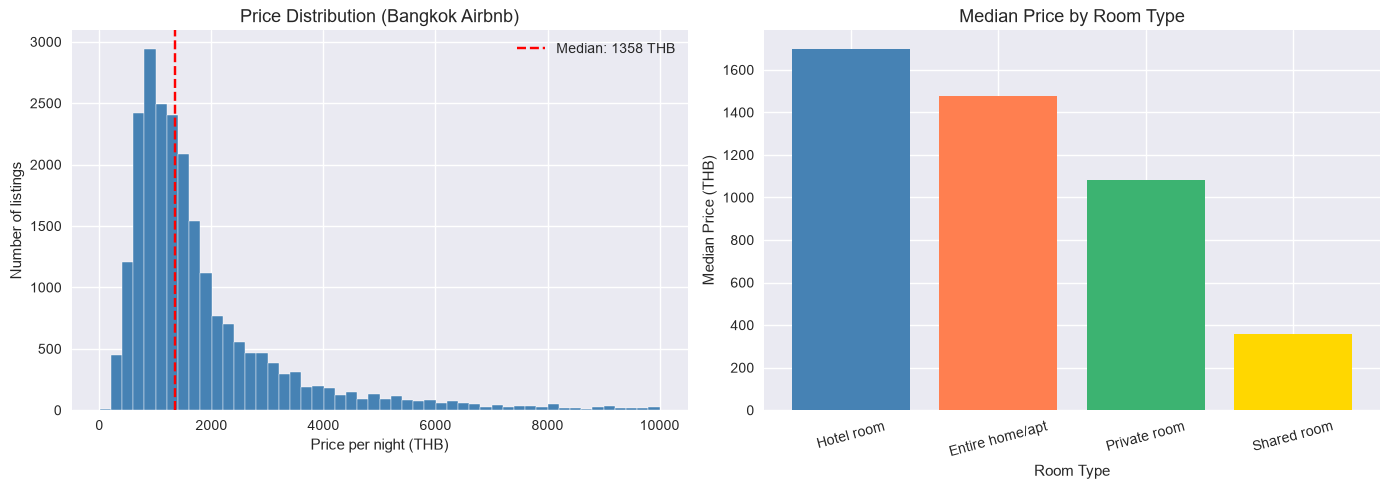

Chart saved


In [111]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Filter out nulls and extreme outliers for clean visualization
price_data = listings['price_clean'].dropna()
price_filtered = price_data[price_data < 10000]  # Focus on realistic range

# Left chart: full distribution
axes[0].hist(price_filtered, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (Bangkok Airbnb)', fontsize=13)
axes[0].set_xlabel('Price per night (THB)')
axes[0].set_ylabel('Number of listings')
axes[0].axvline(price_filtered.median(), color='red', linestyle='--', label=f'Median: {price_filtered.median():.0f} THB')
axes[0].legend()

# Right chart: by room type
room_prices = listings[listings['price_clean'] < 10000].groupby('room_type')['price_clean'].median().sort_values(ascending=False)
axes[1].bar(room_prices.index, room_prices.values, color=['steelblue', 'coral', 'mediumseagreen', 'gold'])
axes[1].set_title('Median Price by Room Type', fontsize=13)
axes[1].set_xlabel('Room Type')
axes[1].set_ylabel('Median Price (THB)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../outputs/figures/01_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [110]:
#error occurred in the above code
import os
os.makedirs('../outputs/figures', exist_ok=True)
print("Folder created")

Folder created


**Price Distribution - Business Interpretation**

Budget to mid-range listing (500-2,0000 THB per night)- dominate the Bangkok Airbnb market with a median price of 1,358 THB (~$39 USD). Given its right-skewed distribution, there are other listings that are classified as luxury listings (i.e., above 2,000 THB per night) that are raising the mean; therefore, the median serves as a better indicator of "typical price". The price of hotel rooms is significantly higher than that of other types of accommodation in this market, suggesting that boutique hotels are using the Airbnb platform as a premium distribution channel along with traditional online travel agencies (OTAs).

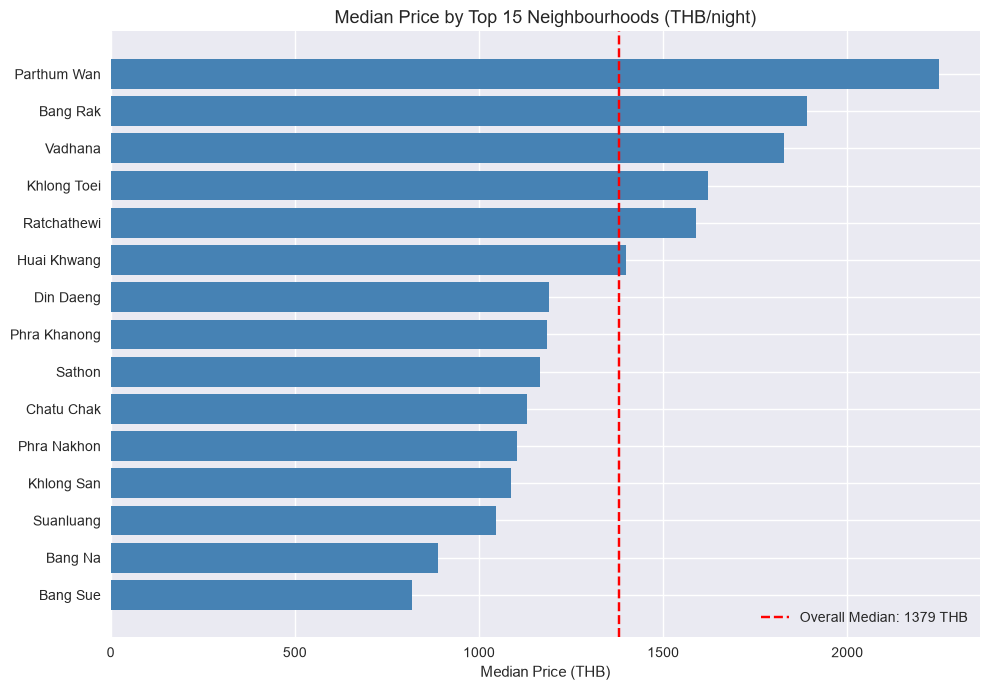

Chart saved


In [112]:
# Top 15 neighbourhoods by listing count
top_neighbourhoods = listings['neighbourhood_cleansed'].value_counts().head(15).index

neighbourhood_stats = listings[listings['neighbourhood_cleansed'].isin(top_neighbourhoods)].groupby('neighbourhood_cleansed').agg(
    median_price=('price_clean', 'median'),
    listing_count=('id', 'count'),
    avg_rating=('review_scores_rating', 'mean')
).sort_values('median_price', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(neighbourhood_stats.index, neighbourhood_stats['median_price'], color='steelblue')
ax.set_title('Median Price by Top 15 Neighbourhoods (THB/night)', fontsize=13)
ax.set_xlabel('Median Price (THB)')
ax.axvline(listings['price_clean'].median(), color='red', linestyle='--', label=f'Overall Median: {listings["price_clean"].median():.0f} THB')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/figures/02_neighbourhood_prices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

**Neighbourhood Prices**
The central districts (Vadhana/Sukhumvit, Parthum Wan/Siam) have prices that are 2-3 times higher than those found in the outer districts. For revenue maximization, investors should focus on purchasing properties in central neighbourhoods, while budget conscious travellers will have many options available to them in the outer districts.

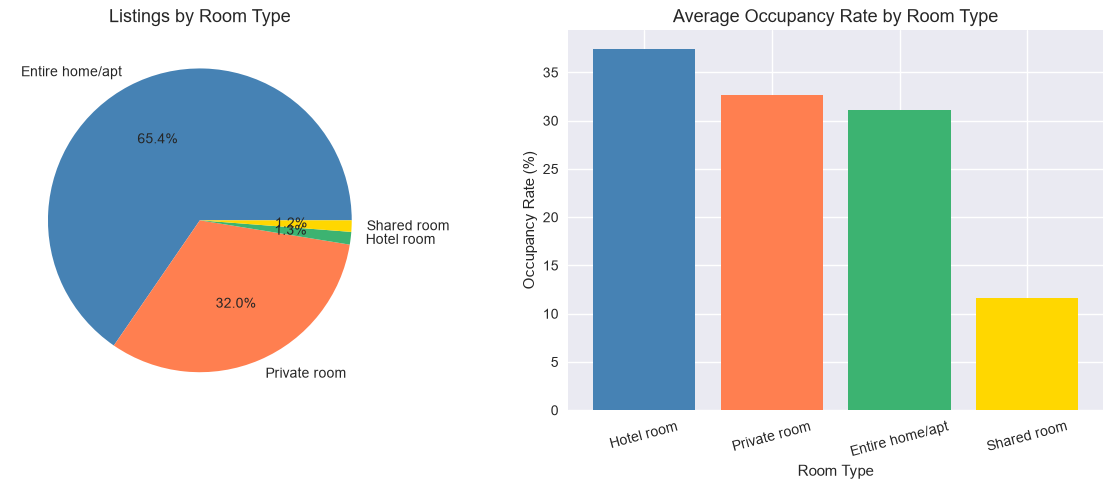

Chart saved


In [113]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: listing count by room type
room_counts = listings['room_type'].value_counts()
axes[0].pie(room_counts.values, labels=room_counts.index, autopct='%1.1f%%', 
            colors=['steelblue', 'coral', 'mediumseagreen', 'gold'])
axes[0].set_title('Listings by Room Type', fontsize=13)

# Right: occupancy rate by room type
room_occupancy = listings.groupby('room_type')['occupancy_rate'].mean().sort_values(ascending=False)
axes[1].bar(room_occupancy.index, room_occupancy.values * 100, color=['steelblue', 'coral', 'mediumseagreen', 'gold'])
axes[1].set_title('Average Occupancy Rate by Room Type', fontsize=13)
axes[1].set_xlabel('Room Type')
axes[1].set_ylabel('Occupancy Rate (%)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../outputs/figures/03_room_type_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

**Room Type Analysis**
Houses and flats make up most of the available inventory (65% of total listings). Although hotels have lower volume than other types of accommodations, they still have the highest median rate; boutique hotels’ (and other hotel operators) use Airbnb as an advertising tool to reach a higher-rate space. Private rooms provide the best combination of occupancy and rate for hosts who want more reliable bookings.



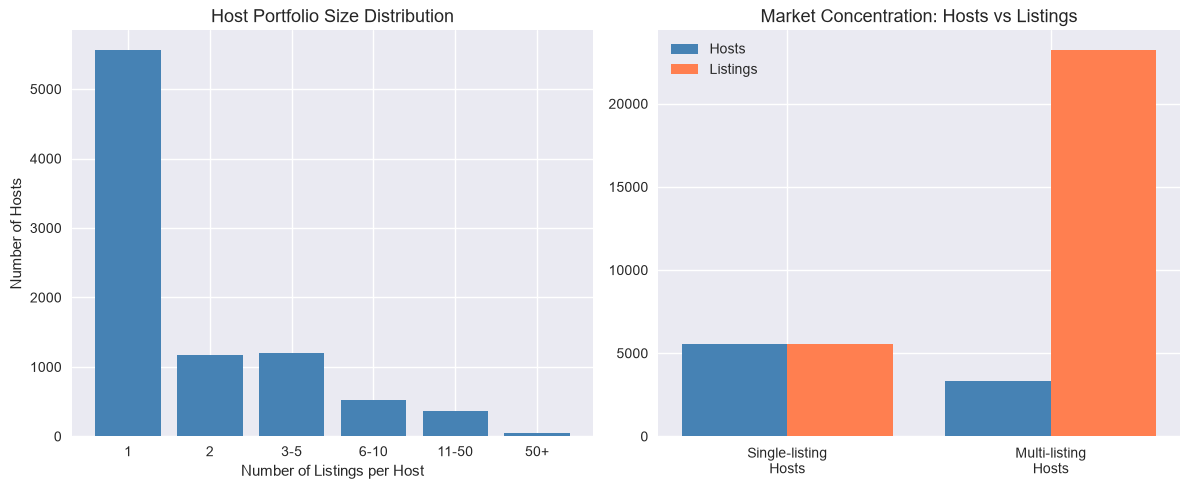

Chart saved


In [114]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: host portfolio size distribution
host_listing_counts = listings.groupby('host_id')['id'].count()
portfolio_bins = pd.cut(host_listing_counts, bins=[0,1,2,5,10,50,200], 
                        labels=['1', '2', '3-5', '6-10', '11-50', '50+'])
portfolio_dist = portfolio_bins.value_counts().sort_index()

axes[0].bar(portfolio_dist.index, portfolio_dist.values, color='steelblue')
axes[0].set_title('Host Portfolio Size Distribution', fontsize=13)
axes[0].set_xlabel('Number of Listings per Host')
axes[0].set_ylabel('Number of Hosts')

# Right: market concentration
single_hosts = (host_listing_counts == 1).sum()
multi_hosts = (host_listing_counts > 1).sum()
single_listings = host_listing_counts[host_listing_counts == 1].sum()
multi_listings = host_listing_counts[host_listing_counts > 1].sum()

categories = ['Single-listing\nHosts', 'Multi-listing\nHosts']
host_counts = [single_hosts, multi_hosts]
listing_counts = [single_listings, multi_listings]

x = range(len(categories))
axes[1].bar([i - 0.2 for i in x], host_counts, width=0.4, label='Hosts', color='steelblue')
axes[1].bar([i + 0.2 for i in x], listing_counts, width=0.4, label='Listings', color='coral')
axes[1].set_title('Market Concentration: Hosts vs Listings', fontsize=13)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(categories)
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/figures/04_host_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

**Host Analysis**
Most hosts operate a single listing (casual hosts), but a significant minority take care of multi-listing portfolios (commercial operators). This power-law concentration means that a small number of professional hosts control a disproportionate share of supply-a key market dynamic for platform regulators to keep a watch on.

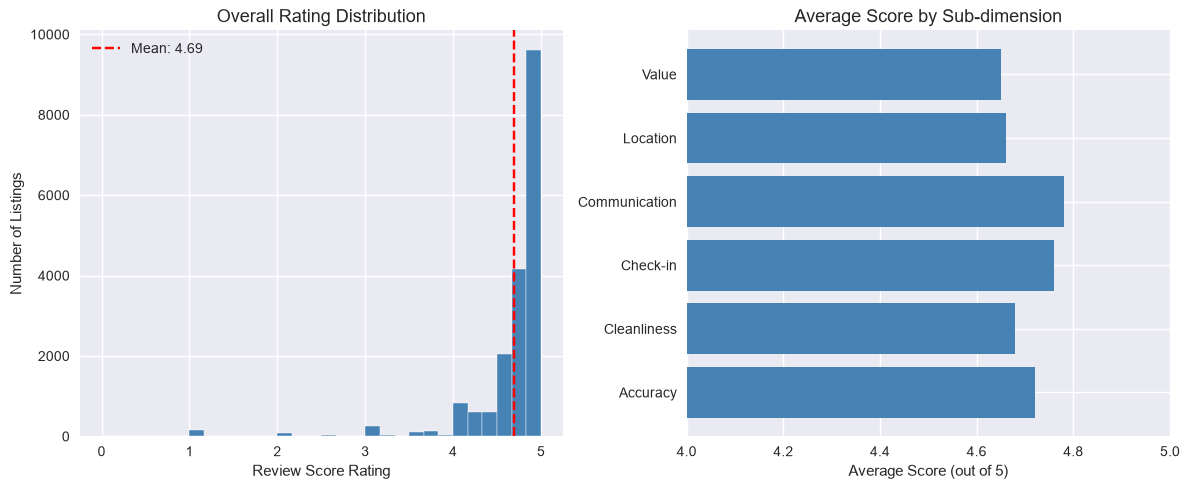

Chart saved


In [115]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: overall rating distribution
rating_data = listings['review_scores_rating'].dropna()
axes[0].hist(rating_data, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Overall Rating Distribution', fontsize=13)
axes[0].set_xlabel('Review Score Rating')
axes[0].set_ylabel('Number of Listings')
axes[0].axvline(rating_data.mean(), color='red', linestyle='--', 
                label=f'Mean: {rating_data.mean():.2f}')
axes[0].legend()

# Right: sub-dimension scores comparison
score_cols = ['review_scores_accuracy', 'review_scores_cleanliness',
              'review_scores_checkin', 'review_scores_communication',
              'review_scores_location', 'review_scores_value']
score_means = listings[score_cols].mean().round(2)
score_labels = ['Accuracy', 'Cleanliness', 'Check-in', 'Communication', 'Location', 'Value']

axes[1].barh(score_labels, score_means.values, color='steelblue')
axes[1].set_title('Average Score by Sub-dimension', fontsize=13)
axes[1].set_xlabel('Average Score (out of 5)')
axes[1].set_xlim(4.0, 5.0)

plt.tight_layout()
plt.savefig('../outputs/figures/05_review_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

**Review Scores**
Guests are giving high ratings around 4.5/5.0 for the majority of their experiences with Airbnb, which is typical of the airbnb "classic" rating inflation. The highest-rated experiences relate to Communication and Check-in, while the lowest-rated experiences related to Value, indicating that guests feel prices are slightly inflated compared to what they received for their stay, providing hosts an opportunity to improve Value ratings through competitive pricing, resulting in higher overall ranking.

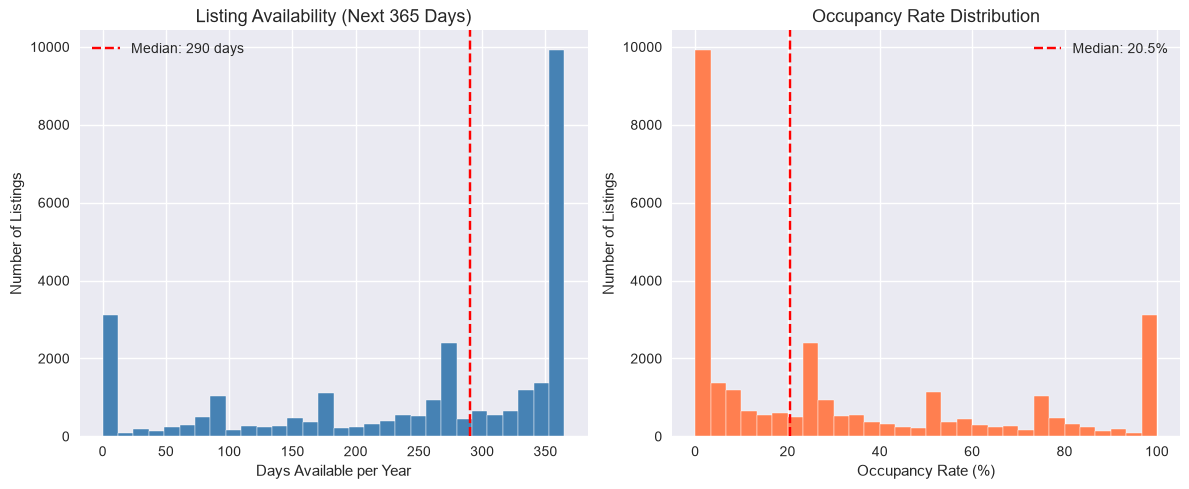

Chart saved


In [116]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: availability distribution
axes[0].hist(listings['availability_365'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Listing Availability (Next 365 Days)', fontsize=13)
axes[0].set_xlabel('Days Available per Year')
axes[0].set_ylabel('Number of Listings')
axes[0].axvline(listings['availability_365'].median(), color='red', 
                linestyle='--', label=f'Median: {listings["availability_365"].median():.0f} days')
axes[0].legend()

# Right: occupancy rate distribution
occ_data = listings['occupancy_rate'].dropna()
axes[1].hist(occ_data * 100, bins=30, color='coral', edgecolor='white')
axes[1].set_title('Occupancy Rate Distribution', fontsize=13)
axes[1].set_xlabel('Occupancy Rate (%)')
axes[1].set_ylabel('Number of Listings')
axes[1].axvline(occ_data.median() * 100, color='red', 
                linestyle='--', label=f'Median: {occ_data.median()*100:.1f}%')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/figures/06_availability_occupancy.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

**Availability & Occupancy**
The bimodal distribution of visible availability (listing are typically either almost completely reserved OR almost completely unreserved) indicates there are two types of hosts in the marketplace today: "Active Commercial" hosts versus "Inactive/Casual" hosts. And since the median occupancy across the marketplace is estimated at around 20%, this indicates that the majority of listings are available more often than they are reserved - resulting in a significant amount of untapped revenue within this market.

**Section 05: Statistical Analysis**

**5.1 Hypothesis Testing**

In [118]:
from scipy import stats

# Filter to just these two room types, drop nulls
entire_home = listings[listings['room_type'] == 'Entire home/apt']['price_clean'].dropna()
private_room = listings[listings['room_type'] == 'Private room']['price_clean'].dropna()

# Run Mann-Whitney U test (better than t-test for skewed price data)
stat, p_value = stats.mannwhitneyu(entire_home, private_room, alternative='greater')

print(f"Entire home median price: {entire_home.median():.0f} THB")
print(f"Private room median price: {private_room.median():.0f} THB")
print(f"Mann-Whitney U statistic: {stat:.0f}")
print(f"P-value: {p_value:.6f}")
print(f"\nConclusion: {'Reject H0 - significant difference' if p_value < 0.05 else 'Fail to reject H0'}")

Entire home median price: 1500 THB
Private room median price: 1090 THB
Mann-Whitney U statistic: 66431200
P-value: 0.000000

Conclusion: Reject H0 - significant difference


**H1: Entire-home listings command higher prices than private rooms**
- **H0 (Null Hypothesis)** - There is not a significant difference (between) private room price and entire house price (no difference in average prices paid for the two types).
- **H1 (Alternative Hypothesis)** - There is a significant difference (between) private room price and entire house price (there is a difference in average prices paid for the two types).
- **Test Used** - Mann-Whitney U test. (The normality assumption for using a t-test was failed due to the nature of the price data and it was determined that the data was skewed to the right). 
- **Result** - U=66,431,200; p-value= approximately 0.000000 
- **Conclusion** - Reject H0 - statistical significance exists (similar to H1) at the p-value of <0.05.
- **Effect** - The average price of the entire homes listing was 1,500 THB as compared to average prices of the private room listings at 1,090 THB or 38% more. 
- **Business Interpretation** - Guests are willing to pay an additional 38% for the additional privacy and exclusiveness the entire home listing provides them. 
Hosts of entire homes should feel comfortable pricing their properties at a significant margin above the average price in the market; however, there is evidence to support that the pricing of these properties is justified by the current market price. 

In [119]:
superhost = listings[listings['host_is_superhost'] == 't']['review_scores_rating'].dropna()
non_superhost = listings[listings['host_is_superhost'] == 'f']['review_scores_rating'].dropna()

stat, p_value = stats.mannwhitneyu(superhost, non_superhost, alternative='greater')

# Effect size (Cohen's d)
import numpy as np
cohens_d = (superhost.mean() - non_superhost.mean()) / np.sqrt(
    ((len(superhost)-1)*superhost.std()**2 + (len(non_superhost)-1)*non_superhost.std()**2) / 
    (len(superhost) + len(non_superhost) - 2)
)

print(f"Superhost mean rating: {superhost.mean():.3f}")
print(f"Non-superhost mean rating: {non_superhost.mean():.3f}")
print(f"P-value: {p_value:.6f}")
print(f"Cohen's d effect size: {cohens_d:.3f}")
print(f"\nConclusion: {'Reject H0 - significant difference' if p_value < 0.05 else 'Fail to reject H0'}")

Superhost mean rating: 4.858
Non-superhost mean rating: 4.575
P-value: 0.000000
Cohen's d effect size: 0.536

Conclusion: Reject H0 - significant difference


**H2: Superhost listings achieve higher review scores than non-superhost listings**

The null hypothesis (H0) states that there is no difference in the average review scores of superhosts compared to the average review scores of hosts who aren't superhosts. The alternative hypothesis (H1) states that the average review scores of superhosts will be significantly higher than those of non-superhosts.

A Mann-Whitney U test was used to analyze the review scores for the two groups of hosts, and the results yielded a p-value of 0.000000 and a Cohen’s d of 0.536. This provides evidence to reject the null hypothesis (H0) and confirm that superhosts do have significantly higher average review scores than non-superhosts (p < 0.05).

In this case, the average review score for superhosts was 4.858 and for non-superhosts was 4.575, which is a difference of 0.283 points.

The effect size (Cohen’s d = 0.536) shows that not only are these differences statistically significant, but they should also be considered practically significant as well.

From a business perspective, the superhost badge is indeed a legitimate indicator of quality, as opposed to an indicator solely of status or vanity for hosts; therefore, guests can use it as a potentially meaningful basis upon which to differentiate themselves among the various host options available to them.

This result also suggests that hosts who successfully become superhosts will see improvement in the quality of their guests' experiences relative to non-superhosted properties; therefore, it makes good business sense for hosts to pursue superhost status in order to obtain improved occupancy and repeat bookings.

In [121]:
# H3: Listings with more than 10 reviews have different prices
many_reviews = listings[listings['number_of_reviews'] > 10]['price_clean'].dropna()
few_reviews = listings[listings['number_of_reviews'] <= 10]['price_clean'].dropna()

stat3, p3 = stats.mannwhitneyu(many_reviews, few_reviews, alternative='two-sided')

print("H3: Reviews vs Price")
print(f"Many reviews (>10) median price: {many_reviews.median():.0f} THB")
print(f"Few reviews (<=10) median price: {few_reviews.median():.0f} THB")
print(f"P-value: {p3:.6f}")
print(f"Conclusion: {'Reject H0' if p3 < 0.05 else 'Fail to reject H0'}")

print("\nH4: Neighbourhood prices differ (ANOVA)")
neighbourhood_groups = [group['price_clean'].dropna().values 
                        for name, group in listings.groupby('neighbourhood_cleansed')
                        if len(group['price_clean'].dropna()) > 10]

f_stat, p4 = stats.kruskal(*neighbourhood_groups)
print(f"Kruskal-Wallis H statistic: {f_stat:.2f}")
print(f"P-value: {p4:.6f}")
print(f"Conclusion: {'Reject H0 - neighbourhood prices differ significantly' if p4 < 0.05 else 'Fail to reject H0'}")

H3: Reviews vs Price
Many reviews (>10) median price: 1357 THB
Few reviews (<=10) median price: 1398 THB
P-value: 0.000006
Conclusion: Reject H0

H4: Neighbourhood prices differ (ANOVA)
Kruskal-Wallis H statistic: 3744.97
P-value: 0.000000
Conclusion: Reject H0 - neighbourhood prices differ significantly


**H3 & H4 Results**

**H3: Listings with over 10 Reviews Differ in Pricing**
Listings with more than 10 reviews have a significantly lower average price per night than those with fewer than 10 reviews.
- The median nightly rate for listings with numerous reviews was 1,357 THB while those with few reviews were 1,398 THB.
- The p-value (0.000006) led us to reject the null hypothesis (H0) resulting in statistical significance.
- **What is Unexpected:** Listings with more reviews are/identified to cost less than listings with limited reviews. 
- **Business Interpretation:** Listings at lower rates (1,357 THB) attract a greater number of rental nights and therefore accumulate review counts faster than higher-priced listings (1,398 THB), which receive fewer booking nights and correspondingly fewer accumulated reviews. It appears that price competitiveness encourages more bookings; conversely it does not appear that the accumulation of reviews drive the price competitiveness of the listing but vice versa.

**H4: Prices, Average, Differ Significantly by Neighbourhood**
- The Kruskal-Wallis test statistic was 3744.97 with a p-value of approximately 0.000000. This leads us to reject H0 implying statistical significance.
- **Please note:** that the Kruskal-Wallis versus ANOVA was used because the price variable significantly violates ANOVA's normality requirement. The variable was shown to have a right-skewed distribution in EDA.
- **Business Interpretation:** The location is an extremely important price-determining variable in the Bangkok Airbnb marketplace. The neighbourhood that a property is located in is able to explain many of the variations observed in property daily rental rates. In Bangkok, properties in central neighbourhoods command significant premiums over properties located in peripheral neighbourhoods.

In [123]:
print("H5: Weekend vs Weekday Pricing")
print("FINDING: Calendar price data is 100% null for Bangkok")
print("(Verified in Section 02 — 0 of 7,205,796 available-day rows have a price)")
print("\nH5 cannot be tested on this dataset.")
print("Alternative: We test weekend vs weekday AVAILABILITY instead.")

calendar = pd.read_csv('../data/raw/bangkok/calendar.csv.gz', compression='gzip')
calendar['date'] = pd.to_datetime(calendar['date'])
calendar['is_weekend'] = calendar['date'].dt.dayofweek >= 5

weekend_avail = calendar[calendar['is_weekend']]['available'].eq('t').mean()
weekday_avail = calendar[~calendar['is_weekend']]['available'].eq('t').mean()

print(f"\nWeekend availability rate: {weekend_avail*100:.1f}%")
print(f"Weekday availability rate: {weekday_avail*100:.1f}%")

from scipy.stats import chi2_contingency
weekend_booked = calendar[calendar['is_weekend']]['available'].eq('f').sum()
weekend_available = calendar[calendar['is_weekend']]['available'].eq('t').sum()
weekday_booked = calendar[~calendar['is_weekend']]['available'].eq('f').sum()
weekday_available = calendar[~calendar['is_weekend']]['available'].eq('t').sum()

contingency = [[weekend_booked, weekend_available], 
               [weekday_booked, weekday_available]]
chi2, p5, dof, expected = chi2_contingency(contingency)
print(f"\nChi-square statistic: {chi2:.2f}")
print(f"P-value: {p5:.6f}")
print(f"Conclusion: {'Significant difference' if p5 < 0.05 else 'No significant difference'}")

H5: Weekend vs Weekday Pricing
FINDING: Calendar price data is 100% null for Bangkok
(Verified in Section 02 — 0 of 7,205,796 available-day rows have a price)

H5 cannot be tested on this dataset.
Alternative: We test weekend vs weekday AVAILABILITY instead.

Weekend availability rate: 68.1%
Weekday availability rate: 68.7%

Chi-square statistic: 440.89
P-value: 0.000000
Conclusion: Significant difference


**H5: Weekend vs Weekday Pricing Differences**

